# First Bottle-Coming Frame Detector + Visualization

This notebook detects the **first frame where the bottle enters the scene** using fast OpenCV image processing.

It is designed for your situation:

- the background is stable
- bottles come from the left side
- nothing changes except the bottle entering
- you want to detect the **first coming bottle frame**
- you want to **visualize** the result clearly

## Main idea

```text
empty background
→ current frame
→ absdiff(background, current)
→ threshold
→ morphology
→ count foreground pixels
→ find largest contour area
→ require 2 or more consecutive positive frames
→ first bottle-coming frame
```

## What this notebook shows

- first frame from the video
- background model
- ROI
- absdiff image
- threshold masks
- cleaned mask
- contours
- final overlay with bounding box and center
- threshold sweep visualization
- automatic detection of the first bottle-coming frame

## 1. Install requirements

If needed:

```bash
pip install opencv-python numpy matplotlib pandas
```

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 2. Configuration

Change `VIDEO_PATH` to your own video.

Recommended first settings based on your previous threshold visualizations:

- `DIFF_THRESHOLD = 35` or `45`
- bottom-half ROI
- use both:
  - foreground pixel count
  - largest contour area

In [2]:
# -----------------------------
# Input video
# -----------------------------
VIDEO_PATH = Path("../data/5.avi")   # change if needed

# -----------------------------
# Background / ROI
# -----------------------------
BACKGROUND_WARMUP_FRAMES = 30   # first frames should contain no bottle
ROI_MODE = "bottom_half"        # "full", "bottom_half", or "custom"
CUSTOM_ROI = (0, 360, 1280, 720)          # x1,y1,x2,y2 if ROI_MODE='custom'

# -----------------------------
# Detection thresholds
# -----------------------------
DIFF_THRESHOLD = 35
MORPH_KERNEL_SIZE = 7

MIN_FOREGROUND_PIXELS = 2500
MIN_LARGEST_CONTOUR_AREA = 1500
CONSECUTIVE_FRAMES_REQUIRED = 2

# -----------------------------
# Threshold sweep candidates for visualization
# -----------------------------
THRESHOLD_SWEEP = [15, 25, 35, 45, 60, 80]

print("VIDEO_PATH:", VIDEO_PATH)

VIDEO_PATH: ..\data\5.avi


## 3. Helper functions

In [3]:
def open_video(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")
    return cap


def get_video_info(video_path):
    cap = open_video(video_path)
    info = {
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    cap.release()
    return info


def get_roi_rect(frame_shape, mode="bottom_half", custom_roi=None):
    h, w = frame_shape[:2]

    if mode == "full":
        return 0, 0, w, h

    if mode == "bottom_half":
        return 0, h // 2, w, h

    if mode == "custom":
        if custom_roi is None:
            raise ValueError("custom_roi is required when mode='custom'")
        x1, y1, x2, y2 = custom_roi
        x1 = max(0, min(w - 1, int(x1)))
        y1 = max(0, min(h - 1, int(y1)))
        x2 = max(x1 + 1, min(w, int(x2)))
        y2 = max(y1 + 1, min(h, int(y2)))
        return x1, y1, x2, y2

    raise ValueError(f"Unknown ROI mode: {mode}")


def crop_roi(frame, roi_rect):
    x1, y1, x2, y2 = roi_rect
    return frame[y1:y2, x1:x2]


def show_bgr(frame, title=None, figsize=(10, 6)):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def load_frame_by_index(video_path, frame_idx):
    cap = open_video(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    return frame

## 4. Background model

This builds the background from the first `BACKGROUND_WARMUP_FRAMES` frames.

Important: these first frames should contain **no bottle**.

{'fps': 30.00003000003, 'frame_count': 2024, 'width': 1280, 'height': 720}
ROI rect: (0, 360, 1280, 720)


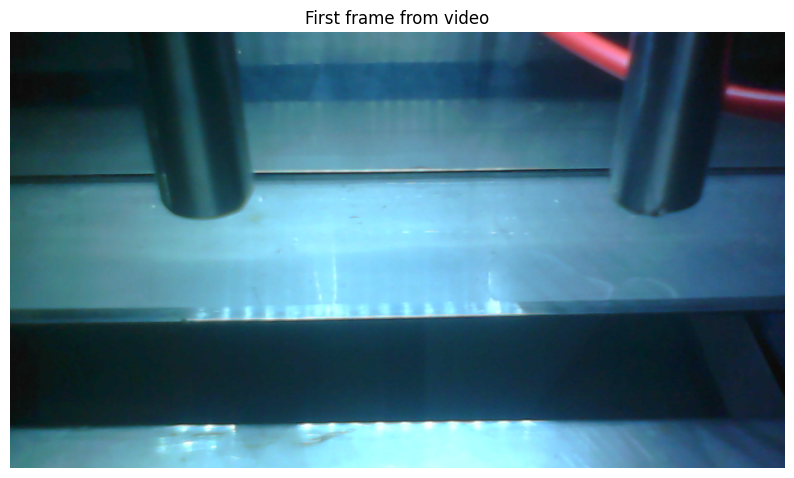

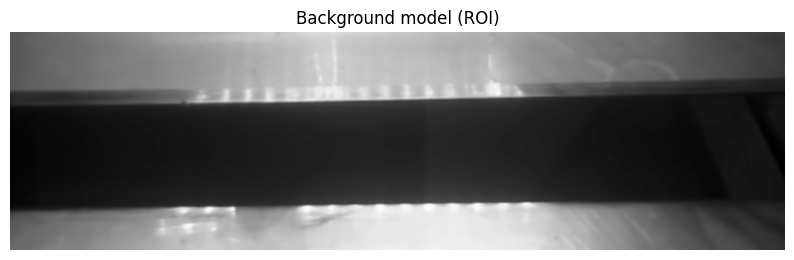

In [4]:
def build_background(video_path, warmup_frames=30, roi_mode="bottom_half", custom_roi=None):
    cap = open_video(video_path)

    frames_gray = []
    first_full_frame = None
    roi_rect = None

    for i in range(warmup_frames):
        ret, frame = cap.read()
        if not ret:
            break

        if first_full_frame is None:
            first_full_frame = frame.copy()
            roi_rect = get_roi_rect(frame.shape, roi_mode, custom_roi)

        roi = crop_roi(frame, roi_rect)
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)
        frames_gray.append(gray)

    cap.release()

    if len(frames_gray) == 0:
        raise RuntimeError("Could not build background. No warmup frames available.")

    background_gray = np.median(np.stack(frames_gray, axis=0), axis=0).astype(np.uint8)
    return background_gray, first_full_frame, roi_rect


video_info = get_video_info(VIDEO_PATH)
print(video_info)

background_gray, first_frame, roi_rect = build_background(
    VIDEO_PATH,
    warmup_frames=BACKGROUND_WARMUP_FRAMES,
    roi_mode=ROI_MODE,
    custom_roi=CUSTOM_ROI
)

print("ROI rect:", roi_rect)
show_bgr(first_frame, "First frame from video")

plt.figure(figsize=(10, 4))
plt.imshow(background_gray, cmap="gray")
plt.title("Background model (ROI)")
plt.axis("off")
plt.show()

## 5. Foreground extraction

In [5]:
def get_foreground(frame, background_gray, roi_rect, diff_threshold=35, morph_kernel_size=7):
    roi = crop_roi(frame, roi_rect)

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    diff = cv2.absdiff(background_gray, gray)

    _, mask_raw = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)

    kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
    mask_clean = cv2.morphologyEx(mask_raw, cv2.MORPH_OPEN, kernel)
    mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    largest_area = 0
    largest_box = None

    if contours:
        c = max(contours, key=cv2.contourArea)
        largest_area = cv2.contourArea(c)
        x, y, w, h = cv2.boundingRect(c)
        largest_box = (x, y, w, h)

    foreground_pixels = cv2.countNonZero(mask_clean)

    return {
        "roi": roi,
        "gray": gray,
        "diff": diff,
        "mask_raw": mask_raw,
        "mask_clean": mask_clean,
        "contours": contours,
        "largest_area": float(largest_area),
        "largest_box": largest_box,
        "foreground_pixels": int(foreground_pixels),
    }

## 6. Threshold sweep visualization

This is like the visualization you already showed: it helps decide which threshold separates:

- bottle present
- bottle absent

Choose a frame index where the bottle is visible and run this cell.

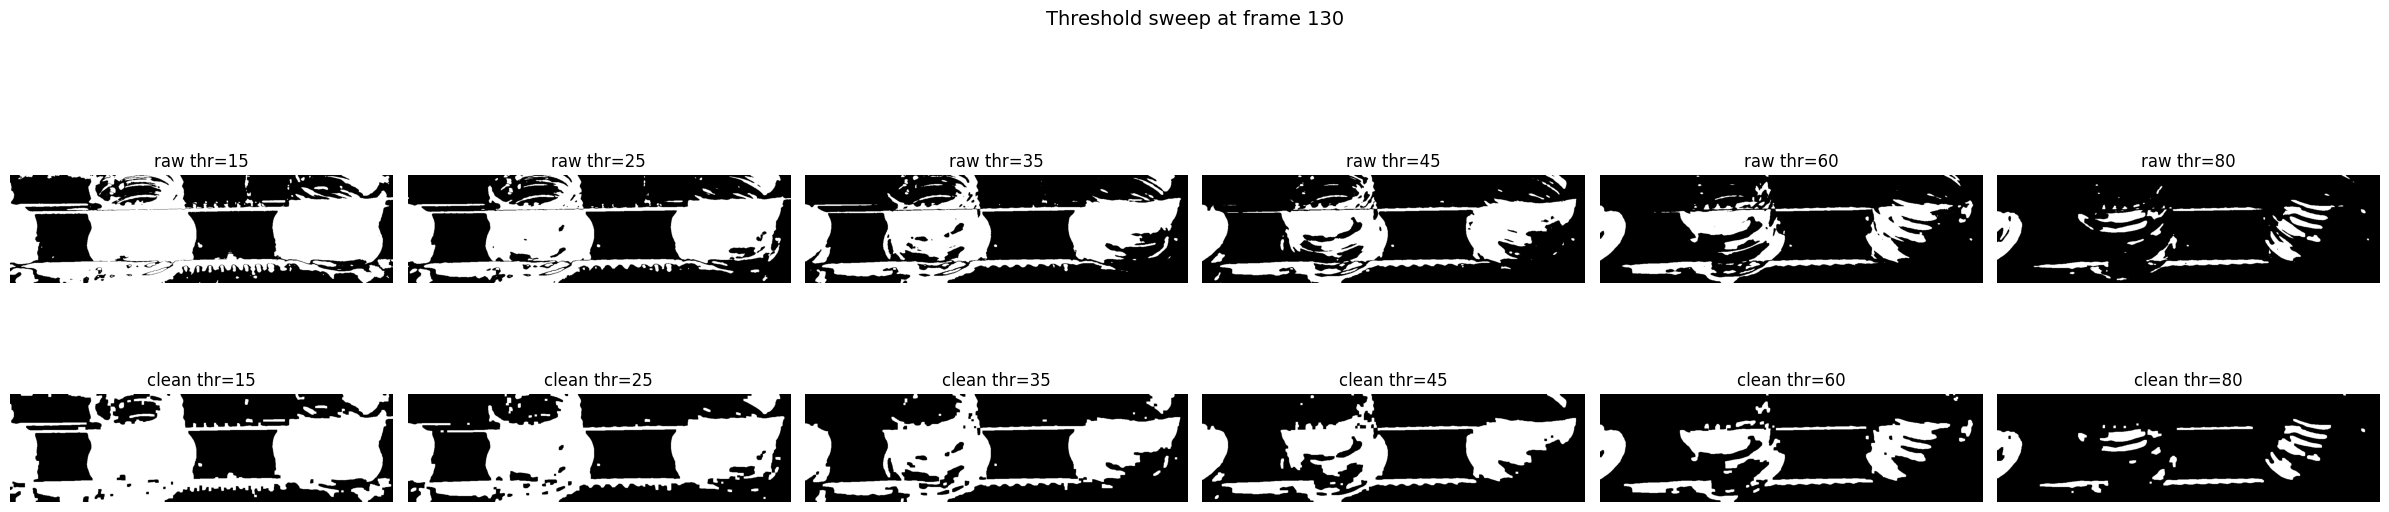

In [7]:
SWEEP_FRAME_INDEX = BACKGROUND_WARMUP_FRAMES + 100   # change if needed

frame_sweep = load_frame_by_index(VIDEO_PATH, SWEEP_FRAME_INDEX)
if frame_sweep is None:
    raise RuntimeError("Could not load SWEEP_FRAME_INDEX.")

results_sweep = []
for thr in THRESHOLD_SWEEP:
    res = get_foreground(
        frame_sweep,
        background_gray,
        roi_rect,
        diff_threshold=thr,
        morph_kernel_size=MORPH_KERNEL_SIZE
    )
    results_sweep.append((thr, res))

plt.figure(figsize=(24, 6))
for i, (thr, res) in enumerate(results_sweep, 1):
    plt.subplot(2, len(results_sweep), i)
    plt.imshow(res["mask_raw"], cmap="gray")
    plt.title(f"raw thr={thr}")
    plt.axis("off")

    plt.subplot(2, len(results_sweep), i + len(results_sweep))
    plt.imshow(res["mask_clean"], cmap="gray")
    plt.title(f"clean thr={thr}")
    plt.axis("off")

plt.suptitle(f"Threshold sweep at frame {SWEEP_FRAME_INDEX}", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 7. Detection logic for first bottle-coming frame

A frame is treated as bottle-present if BOTH are true:

```python
foreground_pixels > MIN_FOREGROUND_PIXELS
largest_area > MIN_LARGEST_CONTOUR_AREA
```

Also, we require this to happen for at least `CONSECUTIVE_FRAMES_REQUIRED` frames.

In [8]:
def bottle_present_from_result(result,
                               min_foreground_pixels=2500,
                               min_largest_contour_area=1500):
    present = (
        result["foreground_pixels"] > min_foreground_pixels and
        result["largest_area"] > min_largest_contour_area
    )
    return present


def detect_first_bottle_frame(video_path,
                              background_gray,
                              roi_rect,
                              start_frame,
                              diff_threshold=35,
                              morph_kernel_size=7,
                              min_foreground_pixels=2500,
                              min_largest_contour_area=1500,
                              consecutive_frames_required=2):
    cap = open_video(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))

    logs = []
    consecutive_count = 0
    first_bottle_frame = None
    first_detection_result = None
    first_detection_full_frame = None

    frame_idx = int(start_frame)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        result = get_foreground(
            frame,
            background_gray,
            roi_rect,
            diff_threshold=diff_threshold,
            morph_kernel_size=morph_kernel_size
        )

        present = bottle_present_from_result(
            result,
            min_foreground_pixels=min_foreground_pixels,
            min_largest_contour_area=min_largest_contour_area
        )

        logs.append({
            "frame": frame_idx,
            "foreground_pixels": result["foreground_pixels"],
            "largest_area": result["largest_area"],
            "present": present
        })

        if present:
            consecutive_count += 1
        else:
            consecutive_count = 0

        if consecutive_count >= consecutive_frames_required:
            first_bottle_frame = frame_idx - consecutive_frames_required + 1
            first_detection_result = result
            first_detection_full_frame = frame.copy()
            break

        frame_idx += 1

    cap.release()
    logs_df = pd.DataFrame(logs)
    return first_bottle_frame, first_detection_full_frame, first_detection_result, logs_df

## 8. Run the first-bottle-frame detector

In [9]:
first_bottle_frame, detected_frame, detected_result, logs_df = detect_first_bottle_frame(
    VIDEO_PATH,
    background_gray,
    roi_rect,
    start_frame=BACKGROUND_WARMUP_FRAMES,
    diff_threshold=DIFF_THRESHOLD,
    morph_kernel_size=MORPH_KERNEL_SIZE,
    min_foreground_pixels=MIN_FOREGROUND_PIXELS,
    min_largest_contour_area=MIN_LARGEST_CONTOUR_AREA,
    consecutive_frames_required=CONSECUTIVE_FRAMES_REQUIRED
)

print("Detected first bottle-coming frame:", first_bottle_frame)
display(logs_df.head(20))
display(logs_df.tail(20))

Detected first bottle-coming frame: 93


,frame,foreground_pixels,largest_area,present
0,30,0,0.0,False
1,31,0,0.0,False
2,32,0,0.0,False
3,33,0,0.0,False
4,34,0,0.0,False
5,35,0,0.0,False
6,36,0,0.0,False
7,37,0,0.0,False
8,38,0,0.0,False
9,39,0,0.0,False


,frame,foreground_pixels,largest_area,present
45,75,0,0.0,False
46,76,0,0.0,False
47,77,0,0.0,False
48,78,0,0.0,False
49,79,0,0.0,False
50,80,0,0.0,False
51,81,0,0.0,False
52,82,0,0.0,False
53,83,0,0.0,False
54,84,0,0.0,False


## 9. Visualize the detected first bottle-coming frame

This is the main visualization section.

It shows:

1. original full frame
2. ROI
3. absdiff
4. raw mask
5. clean mask
6. final overlay with bounding box and center

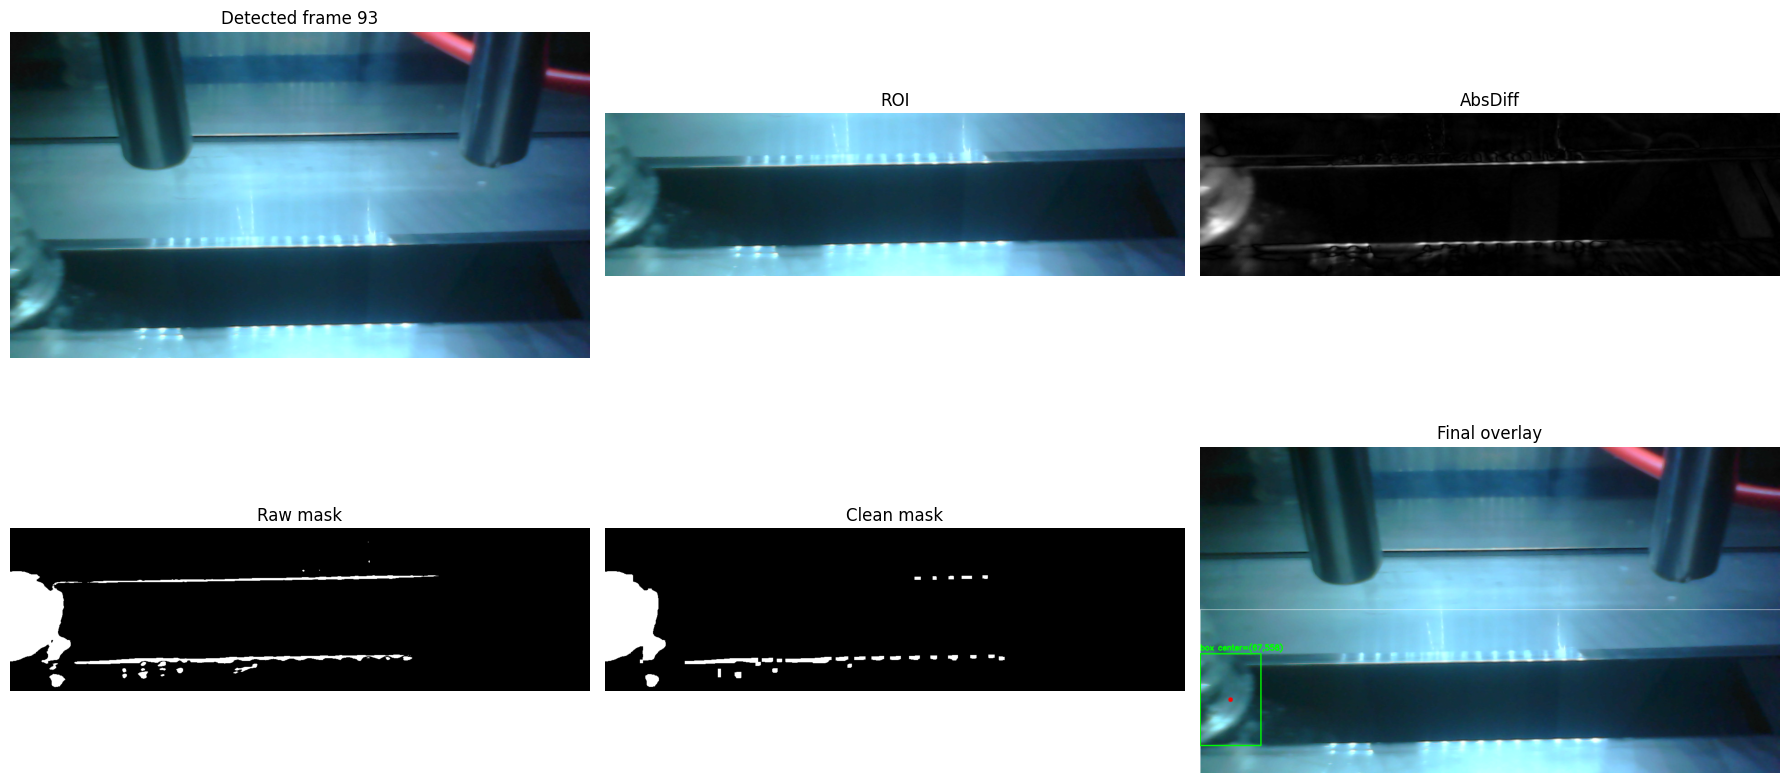

Foreground pixels: 25913
Largest contour area: 19374.5


In [10]:
def draw_result_overlay(full_frame, roi_rect, result):
    overlay = full_frame.copy()

    x1_roi, y1_roi, x2_roi, y2_roi = roi_rect
    cv2.rectangle(overlay, (x1_roi, y1_roi), (x2_roi, y2_roi), (255, 255, 255), 1)

    if result["largest_box"] is not None:
        x, y, w, h = result["largest_box"]

        # convert ROI box to full-frame box
        x1 = x + x1_roi
        y1 = y + y1_roi
        x2 = x1 + w
        y2 = y1 + h

        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.circle(overlay, (cx, cy), 5, (0, 0, 255), -1)

        label = f"box center=({cx},{cy})"
        cv2.putText(
            overlay,
            label,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 0),
            2
        )

    return overlay


if detected_frame is not None and detected_result is not None:
    overlay = draw_result_overlay(detected_frame, roi_rect, detected_result)

    fig = plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(detected_frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected frame {first_bottle_frame}")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(cv2.cvtColor(detected_result["roi"], cv2.COLOR_BGR2RGB))
    plt.title("ROI")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(detected_result["diff"], cmap="gray")
    plt.title("AbsDiff")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(detected_result["mask_raw"], cmap="gray")
    plt.title("Raw mask")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(detected_result["mask_clean"], cmap="gray")
    plt.title("Clean mask")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Final overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Foreground pixels:", detected_result["foreground_pixels"])
    print("Largest contour area:", detected_result["largest_area"])
else:
    print("No bottle-coming frame was detected with current settings.")

## 10. Visualize all contours at the detected frame

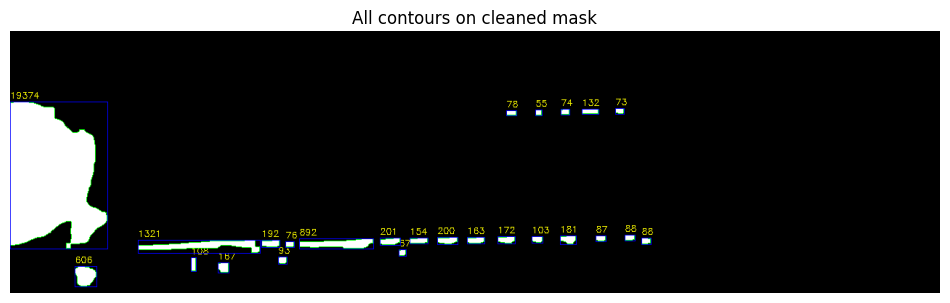

In [11]:
def draw_all_contours(result):
    contour_vis = cv2.cvtColor(result["mask_clean"], cv2.COLOR_GRAY2BGR)

    for c in result["contours"]:
        area = cv2.contourArea(c)
        cv2.drawContours(contour_vis, [c], -1, (0, 255, 0), 1)

        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(contour_vis, (x, y), (x + w, y + h), (255, 0, 0), 1)
        cv2.putText(
            contour_vis,
            f"{int(area)}",
            (x, max(y - 5, 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (0, 255, 255),
            1
        )

    return contour_vis


if detected_result is not None:
    contour_vis = draw_all_contours(detected_result)

    plt.figure(figsize=(12, 5))
    plt.imshow(cv2.cvtColor(contour_vis, cv2.COLOR_BGR2RGB))
    plt.title("All contours on cleaned mask")
    plt.axis("off")
    plt.show()

## 11. Plot the detection metrics over frames

This helps tune the thresholds.

You will see:

- foreground pixel count
- largest contour area
- present/not present

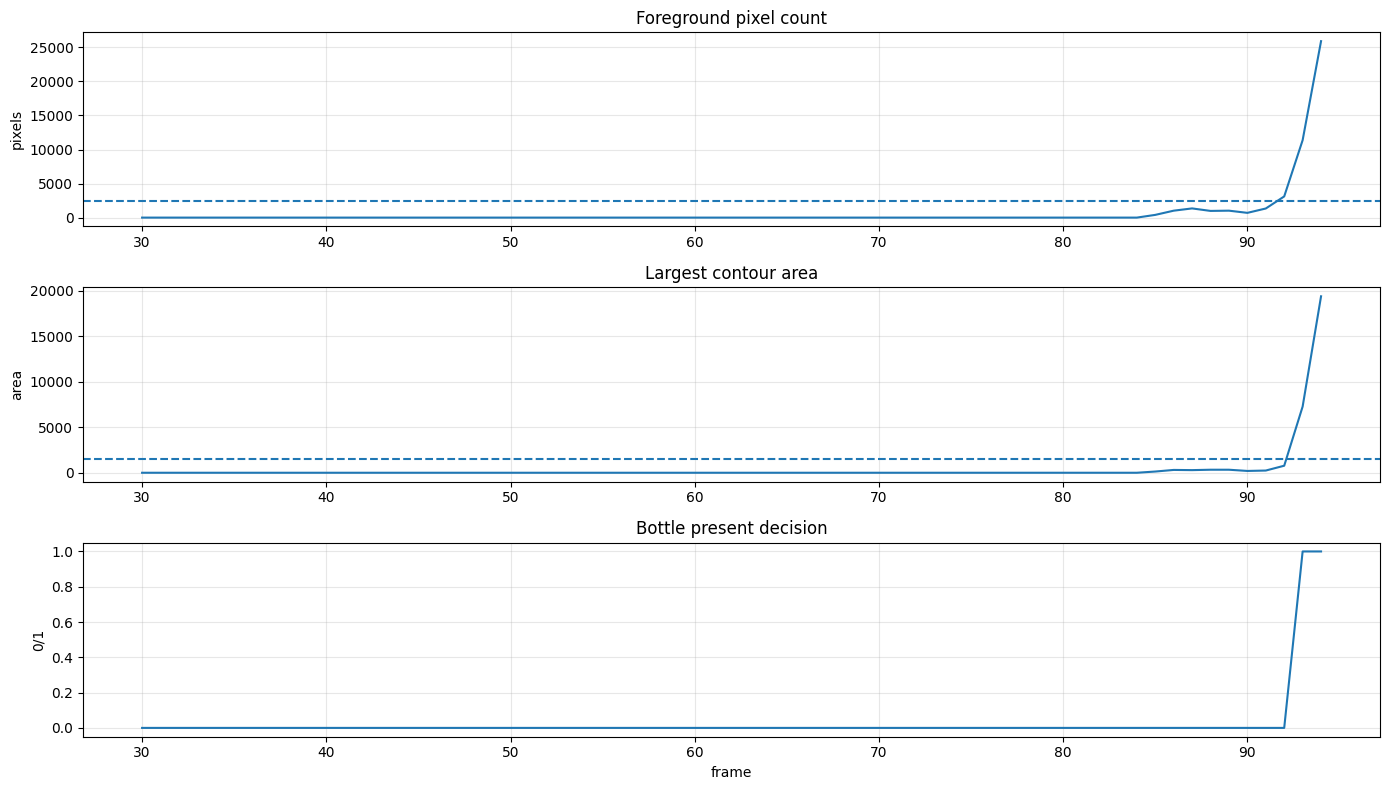

In [12]:
if len(logs_df):
    fig = plt.figure(figsize=(14, 8))

    plt.subplot(3, 1, 1)
    plt.plot(logs_df["frame"], logs_df["foreground_pixels"])
    plt.axhline(MIN_FOREGROUND_PIXELS, linestyle="--")
    plt.title("Foreground pixel count")
    plt.ylabel("pixels")
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 2)
    plt.plot(logs_df["frame"], logs_df["largest_area"])
    plt.axhline(MIN_LARGEST_CONTOUR_AREA, linestyle="--")
    plt.title("Largest contour area")
    plt.ylabel("area")
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(logs_df["frame"], logs_df["present"].astype(int))
    plt.title("Bottle present decision")
    plt.ylabel("0/1")
    plt.xlabel("frame")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 12. Compare bottle frame vs no-bottle frame

This is useful for debugging.

Choose one frame without bottle and one frame with bottle.

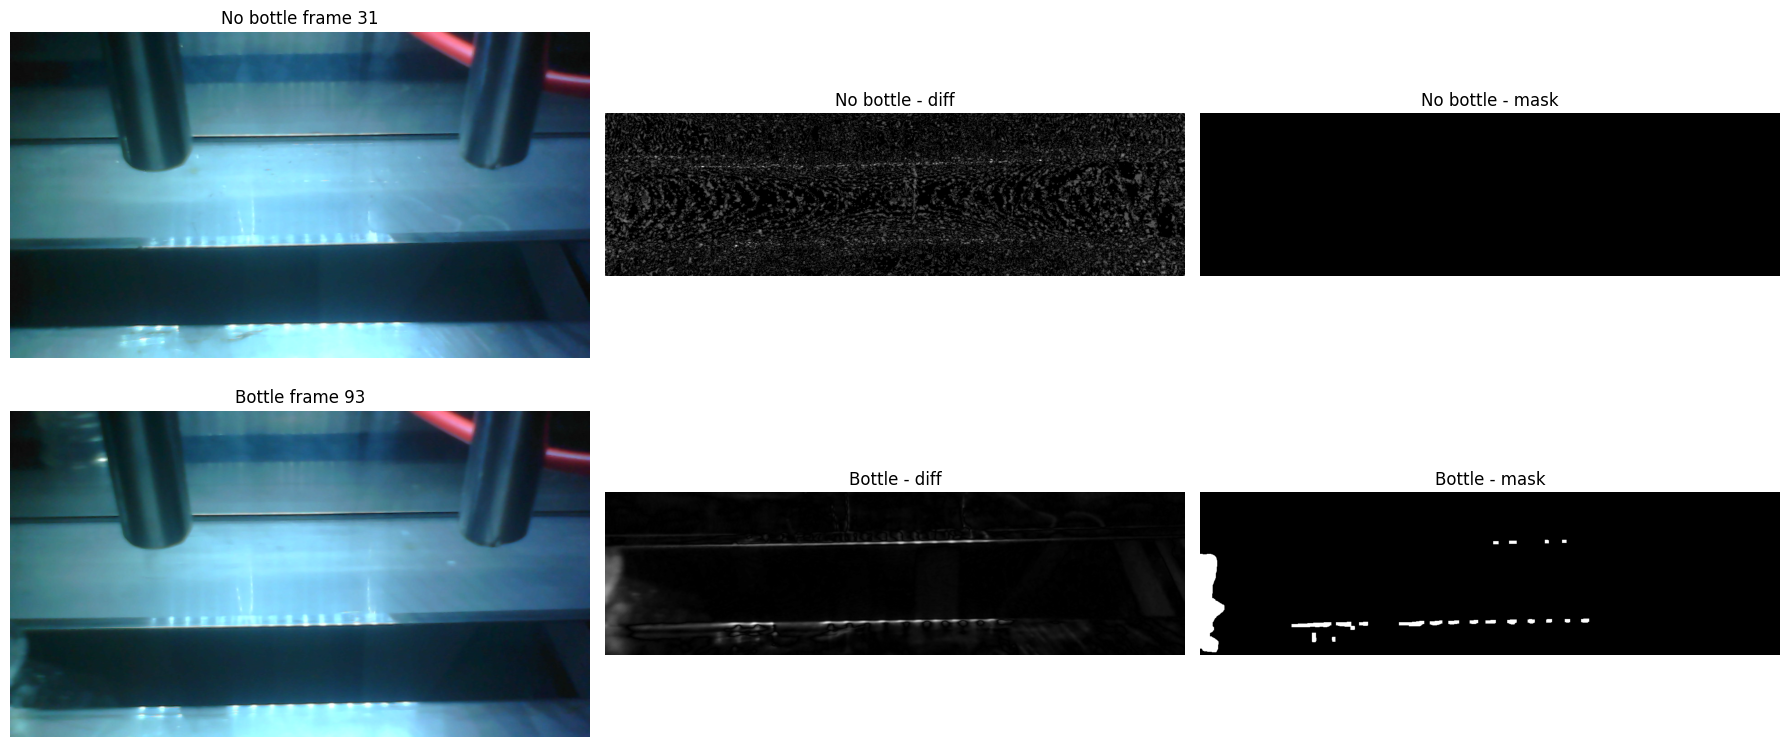

No bottle:
 foreground_pixels = 0
 largest_area      = 0.0

Bottle:
 foreground_pixels = 11370
 largest_area      = 7267.0


In [13]:
NO_BOTTLE_FRAME = BACKGROUND_WARMUP_FRAMES + 1
BOTTLE_FRAME = first_bottle_frame if first_bottle_frame is not None else BACKGROUND_WARMUP_FRAMES + 40

frame_no = load_frame_by_index(VIDEO_PATH, NO_BOTTLE_FRAME)
frame_yes = load_frame_by_index(VIDEO_PATH, BOTTLE_FRAME)

if frame_no is not None and frame_yes is not None:
    res_no = get_foreground(frame_no, background_gray, roi_rect, DIFF_THRESHOLD, MORPH_KERNEL_SIZE)
    res_yes = get_foreground(frame_yes, background_gray, roi_rect, DIFF_THRESHOLD, MORPH_KERNEL_SIZE)

    plt.figure(figsize=(18, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(frame_no, cv2.COLOR_BGR2RGB))
    plt.title(f"No bottle frame {NO_BOTTLE_FRAME}")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(res_no["diff"], cmap="gray")
    plt.title("No bottle - diff")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(res_no["mask_clean"], cmap="gray")
    plt.title("No bottle - mask")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(cv2.cvtColor(frame_yes, cv2.COLOR_BGR2RGB))
    plt.title(f"Bottle frame {BOTTLE_FRAME}")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(res_yes["diff"], cmap="gray")
    plt.title("Bottle - diff")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(res_yes["mask_clean"], cmap="gray")
    plt.title("Bottle - mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("No bottle:")
    print(" foreground_pixels =", res_no["foreground_pixels"])
    print(" largest_area      =", res_no["largest_area"])

    print("\nBottle:")
    print(" foreground_pixels =", res_yes["foreground_pixels"])
    print(" largest_area      =", res_yes["largest_area"])

## 13. Save the first detected frame image

Optional convenience cell.

In [14]:
OUTPUT_DIR = Path("../outputs/first_bottle_frame")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if detected_frame is not None and detected_result is not None:
    overlay = draw_result_overlay(detected_frame, roi_rect, detected_result)

    out_frame = OUTPUT_DIR / f"first_bottle_frame_{first_bottle_frame}.jpg"
    out_mask = OUTPUT_DIR / f"first_bottle_mask_{first_bottle_frame}.png"

    cv2.imwrite(str(out_frame), overlay)
    cv2.imwrite(str(out_mask), detected_result["mask_clean"])

    print("Saved:", out_frame)
    print("Saved:", out_mask)
else:
    print("Nothing to save.")

Saved: ..\outputs\first_bottle_frame\first_bottle_frame_93.jpg
Saved: ..\outputs\first_bottle_frame\first_bottle_mask_93.png


# Recommended tuning order

1. Make sure the first `BACKGROUND_WARMUP_FRAMES` are empty.
2. Use `ROI_MODE = "bottom_half"`.
3. Run the threshold sweep section.
4. Try `DIFF_THRESHOLD = 35` first.
5. Tune:
   - `MIN_FOREGROUND_PIXELS`
   - `MIN_LARGEST_CONTOUR_AREA`
6. Check the metric plots.
7. If there is noise, increase:
   - `DIFF_THRESHOLD`
   - `MORPH_KERNEL_SIZE`
   - `CONSECUTIVE_FRAMES_REQUIRED`

For your video, a good first guess is:

```python
DIFF_THRESHOLD = 35
MIN_FOREGROUND_PIXELS = 2500
MIN_LARGEST_CONTOUR_AREA = 1500
CONSECUTIVE_FRAMES_REQUIRED = 2
```